In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
import seaborn as sns 

plt.style.use('seaborn-v0_8-darkgrid') 
plt.rcParams['figure.figsize'] = (14, 5) 
plt.rcParams['font.size'] = 11

In [2]:
stock = pd.read_csv('apple_stock_2016to2026.csv')
news  = pd.read_csv('stock_news_2016 to 2026.csv', usecols=['date', 'title'])

print('Stock dataset shape:', stock.shape)
print('News dataset shape: ', news.shape)

Stock dataset shape: (2585, 6)
News dataset shape:  (139919, 2)


In [3]:
print('First 5 rows')
stock.head()

=== First 5 rows ===


,date,Close,High,Low,Open,Volume
0,2016-01-04,23.709103,23.713605,22.955183,23.092464,270597600
1,2016-01-05,23.114971,23.821631,23.047457,23.799126,223164000
2,2016-01-06,22.662607,23.038443,22.475816,22.631100,273829600
3,2016-01-07,21.706148,22.534335,21.701648,22.208012,324377600
4,2016-01-08,21.820923,22.304782,21.775913,22.178754,283192000


In [4]:
print('Last 5 rows')
stock.tail()

=== Last 5 rows ===


,date,Close,High,Low,Open,Volume
2580,2026-04-09,260.250214,260.879639,255.834299,258.761595,28121600
2581,2026-04-10,260.240234,261.948652,258.781556,259.740695,31291500
2582,2026-04-13,258.961426,259.940504,256.423755,259.490937,36234700
2583,2026-04-14,258.591736,261.688888,256.953261,259.011363,48370700
2584,2026-04-15,266.184753,266.314639,257.572693,257.922377,49913500


In [5]:
print('Column Data Types')
print(stock.dtypes)

stock['date'] = pd.to_datetime(stock['date'])
print('Date column converted to datetime successfully!')
print('New date dtype:', stock['date'].dtype)

=== Column Data Types ===
date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Date column converted to datetime successfully!
New date dtype: datetime64[ns]


In [6]:
print(' Date Range')
print('Start date:', stock['date'].min().date())
print('End date:  ', stock['date'].max().date())
print('Total trading days:', len(stock))

=== Date Range ===
Start date: 2016-01-04
End date:   2026-04-15
Total trading days: 2585


In [7]:
print('Missing Values in Stock Dataset')
missing = stock.isnull().sum()
print(missing)


=== Missing Values in Stock Dataset ===
date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64



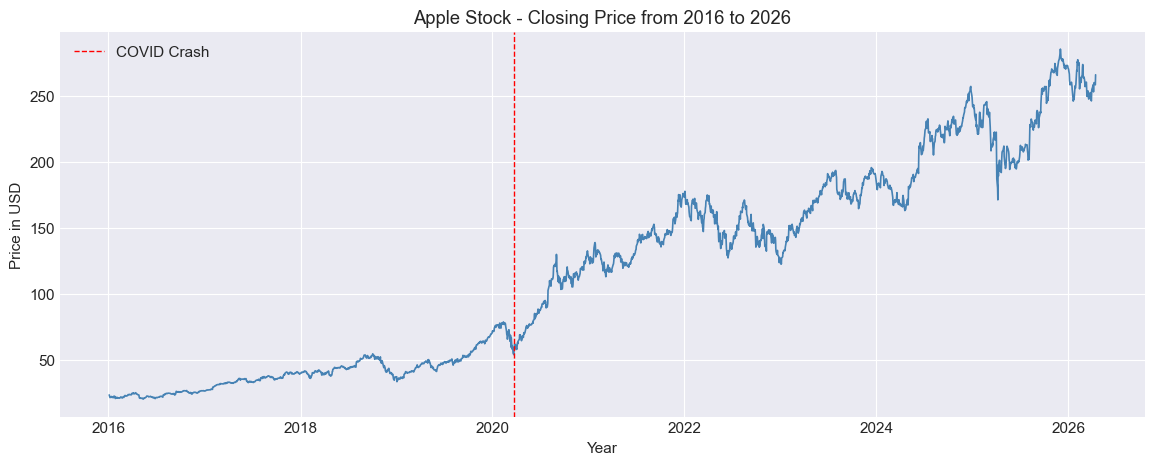

In [8]:
# closing price over time
plt.plot(stock['date'], stock['Close'], color='steelblue', linewidth=1.2)

# axvline draws a vertical line at a specific date
plt.axvline(x = pd.to_datetime('2020-03-23'), color='red',    #global pandamic
            linestyle='--', linewidth=1, label='COVID Crash')

# Add chart title and axis labels
plt.title('Apple Stock - Closing Price from 2016 to 2026')
plt.xlabel('Year')
plt.ylabel('Price in USD')
plt.legend()

plt.savefig('plot1_closing_price.png')

plt.show()

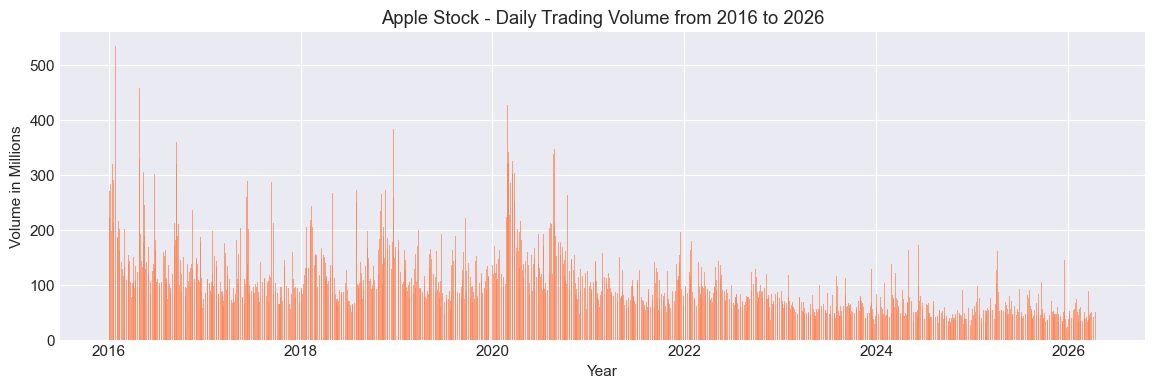

In [9]:
#volume over time
plt.figure(figsize=(14, 4))

plt.bar(stock['date'], stock['Volume'] / 1000000,
        color='coral', width=1.5, alpha=0.7)

plt.title('Apple Stock - Daily Trading Volume from 2016 to 2026')
plt.xlabel('Year')
plt.ylabel('Volume in Millions')
plt.savefig('plot2_volume.png')
plt.show()


In [10]:
# Calculate dailt returns
stock['daily_return'] = stock['Close'].pct_change() * 100

print('Daily return statistic')
print('Average return per day:', round(stock['daily_return'].mean(), 3), '%')
print('Std deviation :', round(stock['daily_return'].std(), 3),  '%')
print('Biggest gain in a day: +' + str(round(stock['daily_return'].max(), 2)) + '%')
print('Biggest loss in a day :  ' + str(round(stock['daily_return'].min(), 2)) + '%')

Daily return statistic
Average return per day: 0.11 %
Std deviation : 1.823 %
Biggest gain in a day: +15.33%
Biggest loss in a day :  -12.86%


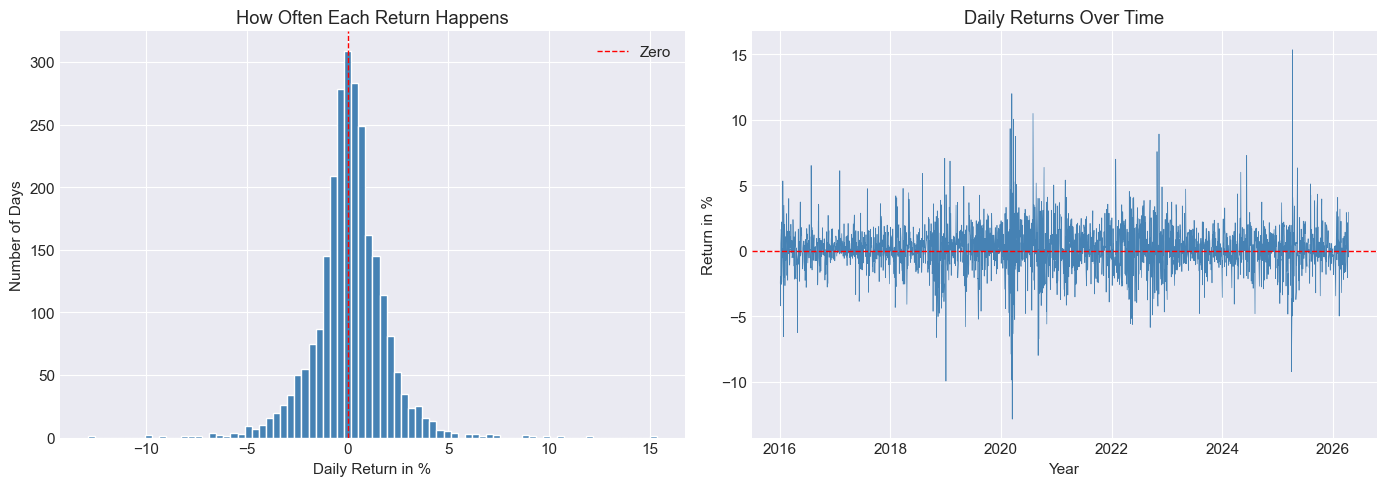

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left chart: Histogram ---
axes[0].hist(stock['daily_return'].dropna(), bins=80,
color='steelblue', edgecolor='white') 

axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='Zero')

axes[0].set_title('How Often Each Return Happens')
axes[0].set_xlabel('Daily Return in %')
axes[0].set_ylabel('Number of Days')
axes[0].legend()

#Returns over time
axes[1].plot(stock['date'], stock['daily_return'],
color='steelblue', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Daily Returns Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Return in %')

plt.tight_layout()
plt.savefig('plot3_daily_returns.png')

In [12]:
#news data set
print('Rows and columns in news dataset:')
print(news.shape)
print(news.head(2))

Rows and columns in news dataset:
(139919, 2)
         date                                              title
0  2016-01-01  Lending to foreign step-down arms of Indian fi...
1  2016-01-02  IDBI Bank to raise Rs 900 cr through Basel-III...


In [13]:
news['date'] = pd.to_datetime(news['date'])

print('Missing values in news dataset:')
print(news.isnull().sum())
print('First date:', news['date'].min().date())
print('Last  date:', news['date'].max().date())
print('Unique dates:', news['date'].nunique())

Missing values in news dataset:
date     0
title    0
dtype: int64
First date: 2016-01-01
Last  date: 2026-04-15
Unique dates: 3182


=== Articles Per Day ===
Average per day : 44.0
Minimum per day : 1
Maximum per day : 196
Busiest day     : 2022-02-01 with 196 articles


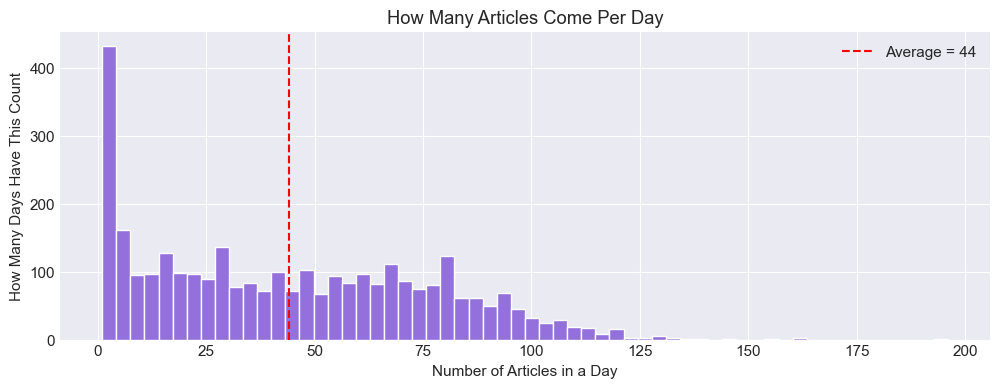

In [14]:
# Count how many articles come on each unique date
articles_per_day = news.groupby('date').size()

print('=== Articles Per Day ===')
print('Average per day :', round(articles_per_day.mean(), 1))
print('Minimum per day :', articles_per_day.min())
print('Maximum per day :', articles_per_day.max())
print('Busiest day     :', articles_per_day.idxmax().date(),
'with', articles_per_day.max(), 'articles')

plt.figure(figsize=(12, 4))
plt.hist(articles_per_day.values, bins=60, color='mediumpurple', edgecolor='white')

avg = articles_per_day.mean()
plt.axvline(avg, color='red', linestyle='--', linewidth=1.5,
            label='Average = ' + str(round(avg)))

plt.title('How Many Articles Come Per Day')
plt.xlabel('Number of Articles in a Day')
plt.ylabel('How Many Days Have This Count')
plt.legend()
plt.savefig('plot4_articles_per_day.png')